In [2]:
# This script trains the DeepHit model on the provided dataset and 
# evaluates its performance using the C-index at a specified time horizon.
# It also includes a permutation feature importance analysis to identify
# which features are most influential for the model's predictions at that horizon.
import os
import random
import numpy as np
import tensorflow as tf
from trainDeepHit import *
from sklearn.model_selection import KFold
from utils_eval import c_index
import pandas as pd
import ImportDatabase as impt
from ClassDeepHit import DeepHitPlus
from sklearn.model_selection import train_test_split
from dotenv import load_dotenv
from pathlib import Path
from lifelines import AalenJohansenFitter
import matplotlib.pyplot as plt

load_dotenv()

True

In [3]:
SEED = 321

num_Event = 2
eval_time = [12]
CV_ITERATION = 5
eval_horizon = 12  # same as eval_time, used for C-index evaluation

def setSeed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["TF_DETERMINISTIC_OPS"] = "1"   # deterministic TF ops
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

setSeed(SEED)

In [8]:
# ==================================================
# Load data
# ==================================================
data_dir = Path(os.getenv("DATA_DIR"))
path = data_dir / "Region_Sthlm_Gotland_model_data_binary.csv"

x_dim, (data, time, label), (mask1, mask2), feature_names = impt.import_dataset(path,time_scale=1.2)
data_df = pd.DataFrame(data, columns=feature_names)
reference_patient = data_df.mode().iloc[0]

# Normalize age and log-transform certain features
age_mean = data[:, 0].mean()
age_std = data[:, 0].std()

data[:, 0] = (data[:, 0] - age_mean) / age_std
reference_patient["Age"] = (reference_patient["Age"] - age_mean) / age_std

for j in range(data.shape[1] - 3, data.shape[1]): 
    data[:, j] = np.log1p(data[:, j])
    data[:, j] = (data[:, j] - data[:, j].mean()) / data[:, j].std()
    reference_patient[feature_names[j]] = (np.log1p(reference_patient[feature_names[j]]) - data[:, j].mean()) / data[:, j].std()


In [ ]:
# ==================================================
# Train / Validation split
# ==================================================
param_grid = {
    "shared_layers": [
        (32, 16),
        (32, 16, 8),
        (64, 32),
        (64, 4),
        (16, 8, 4),
        (16, 8)
    ],
    "MR_layers": [
        (4, 4),
        (4, 8),
        (8, 8),
    ],
    "CR_layers": [
        (4, 4),
        (4, 8),
        (8, 8),
    ],
    "dropout": [0.1, 0.25, 0.4]
}
results_df = optimize_hyperparameters_grid_search(data, time, label, mask1, mask2, param_grid, CV_ITERATION=5, eval_time=[12])






===== START TRAINING =====

Epoch 000 | Train 4.7290 (LL 2.5005, Rank 2.2285) | Test 35.3381 | Test C-index 0.8397 (competing event: 0.4018)
Epoch 001 | Train 3.9367 (LL 2.2139, Rank 1.7228) | Test 30.2667 | Test C-index 0.8493 (competing event: 0.3566)
Epoch 002 | Train 2.7028 (LL 1.2223, Rank 1.4806) | Test 33.7209 | Test C-index 0.8391 (competing event: 0.7899)
Epoch 003 | Train 2.2162 (LL 0.6474, Rank 1.5688) | Test 32.1412 | Test C-index 0.8351 (competing event: 0.7912)
Epoch 004 | Train 1.9512 (LL 0.4433, Rank 1.5079) | Test 32.6701 | Test C-index 0.8387 (competing event: 0.8068)
Epoch 005 | Train 1.8005 (LL 0.4005, Rank 1.4000) | Test 31.8684 | Test C-index 0.8346 (competing event: 0.8017)
Epoch 006 | Train 1.7281 (LL 0.3472, Rank 1.3809) | Test 32.0539 | Test C-index 0.8399 (competing event: 0.8104)
Epoch 007 | Train 1.6852 (LL 0.3380, Rank 1.3472) | Test 30.5679 | Test C-index 0.8386 (competing event: 0.8098)
Epoch 008 | Train 1.5901 (LL 0.3340, Rank 1.2562) | Test 30.5090 | 

In [ ]:
print(results_df)

shared_layers       (32, 16)
MR_layers           (10, 10)
CR_layers            (5, 10)
dropout                  0.1
cindex_MACE         0.861454
cindex_competing    0.872193
Name: 69, dtype: object


In [5]:
# Final traing of the model after cross-validation, with the best hyperparameters, on the entire dataset
'''model = DeepHitPlus(
    num_event=num_Event,
    num_bins=num_bins,
    shared_layers=(30, 15, 5),
    MR_layers=[5, 10],
    CR_layers=(5, 10),
    dropout=0.25   
)'''
num_bins = mask2.shape[1]   # T (time bins)
model = DeepHitPlus(
    num_event=num_Event,
    num_bins=num_bins,
    shared_layers=(32, 16),
    MR_layers=[10, 10],
    CR_layers=(5, 10),
    dropout=0.1   
)

model = TrainDeepHit(model, data, mask1, mask2, time, label,
                eval_time = [12], 
                test_size = 0.2, max_epochs = 100, batch_size = 128, learning_rate = 1e-3, alpha=1.0, beta=1.0)



===== START TRAINING =====

Epoch 000 | Train 4.4589 (LL 2.2418, Rank 2.2171) | Test 45.3040 | Test C-index 0.7827 (competing event: 0.7576)
Epoch 001 | Train 2.4392 (LL 0.6296, Rank 1.8096) | Test 42.4220 | Test C-index 0.8392 (competing event: 0.8558)
Epoch 002 | Train 2.0098 (LL 0.4270, Rank 1.5828) | Test 38.7010 | Test C-index 0.8386 (competing event: 0.8563)
Epoch 003 | Train 1.7914 (LL 0.3345, Rank 1.4570) | Test 36.7080 | Test C-index 0.8325 (competing event: 0.8663)
Epoch 004 | Train 1.7112 (LL 0.3341, Rank 1.3771) | Test 36.1375 | Test C-index 0.8329 (competing event: 0.8607)
Epoch 005 | Train 1.6546 (LL 0.3229, Rank 1.3317) | Test 35.6525 | Test C-index 0.8378 (competing event: 0.8687)
Epoch 006 | Train 1.5899 (LL 0.3274, Rank 1.2624) | Test 34.6619 | Test C-index 0.8371 (competing event: 0.8694)
Epoch 007 | Train 1.5458 (LL 0.3145, Rank 1.2314) | Test 34.3796 | Test C-index 0.8379 (competing event: 0.8655)
Epoch 008 | Train 1.5081 (LL 0.3260, Rank 1.1821) | Test 34.7032 | 

In [ ]:
def permutation_feature_importance(
    model,
    x_val,
    time_val,
    label_val,
    eval_horizon,
    n_repeats=50
):
    """
    Permutation feature importance using drop in C-index.
    Returns array of shape (num_Event, num_features).
    """
    n_features = x_val.shape[1]
    baseline = compute_cindex_at_time(
        model, x_val, time_val, label_val, eval_horizon
    )
    
    importance = np.zeros((num_Event, n_features))

    for j in range(n_features):
        drops = []

        for _ in range(n_repeats):
            x_perm = x_val.copy()
            perm_idx = np.random.permutation(x_perm.shape[0])
            x_perm[:, j] = x_perm[perm_idx, j]

            cidx_perm = compute_cindex_at_time(
                model, x_perm, time_val, label_val, eval_horizon
            )

            drops.append(baseline - cidx_perm)

        importance[:, j] = np.mean(drops, axis=0)

        if j % 10 == 0:
            print(f"PFI done for feature {j}/{n_features}")

    return importance

pfi = permutation_feature_importance(
    model=model,
    x_val=va_data,
    time_val=va_time,
    label_val=va_label,
    eval_horizon=eval_horizon,
    n_repeats=50
)

print("PFI shape:", pfi.shape)  # (num_Event, num_features)


# Top 10 features per event
for k in range(num_Event):
    top_idx = np.argsort(-pfi[k])[:10]

    print(f"\nTop features for event {k+1}:")

    for i in top_idx:
        print(f"{feature_names[i]}: {pfi[k, i]:.3f}")


PFI done for feature 0/88
PFI done for feature 10/88
PFI done for feature 20/88
PFI done for feature 30/88
PFI done for feature 40/88
PFI done for feature 50/88
PFI done for feature 60/88
PFI done for feature 70/88
PFI done for feature 80/88
PFI shape: (2, 88)

Top features for event 1:

Top features for event 1:
['Age', 'MaxHosPeriod', 'VisitCount', 'chemo', 'ATC_L2_C09', 'ATC_L2_C03', 'First_ICDI00_I99_Score', 'J00_J99', 'CVDbefore', 'ATC_L2_C01']


TypeError: unsupported format string passed to numpy.ndarray.__format__

In [7]:
def bootstrap_cindex_at_time(
    model,
    data,
    time,
    label,
    eval_horizon,
    n_bootstrap=1000,
    seed=42
):
    """
    Bootstrap 95% confidence intervals for event-specific C-index.

    Parameters
    ----------
    model : trained DeepHit model
    data : validation features
    time : validation follow-up times
    label : validation labels
    eval_horizon : evaluation time horizon
    n_bootstrap : number of bootstrap samples
    seed : random seed

    Returns
    -------
    baseline : (num_Event,)
        Original C-index on the validation set.

    ci_lower : (num_Event,)
        Lower 95% confidence interval.

    ci_upper : (num_Event,)
        Upper 95% confidence interval.

    bootstrap_scores : (n_bootstrap, num_Event)
        All bootstrap C-index values.
    """

    rng = np.random.default_rng(seed)
    n = len(time)

    # Original estimate
    baseline = compute_cindex_at_time(
        model,
        data,
        time,
        label,
        eval_horizon
    )

    bootstrap_scores = np.zeros((n_bootstrap, num_Event))

    for b in range(n_bootstrap):

        # Sample patients with replacement
        idx = rng.choice(n, size=n, replace=True)

        data_b = data[idx]
        time_b = time[idx]
        label_b = label[idx]

        bootstrap_scores[b] = compute_cindex_at_time(
            model,
            data_b,
            time_b,
            label_b,
            eval_horizon
        )

    ci_lower = np.percentile(bootstrap_scores, 2.5, axis=0)
    ci_upper = np.percentile(bootstrap_scores, 97.5, axis=0)

    return baseline, ci_lower, ci_upper, bootstrap_scores

In [ ]:
path = np.array([
    data_dir / "Region_Uppsala_Örebro_model_data_binary.csv",
    data_dir / "Region_Väst_model_data_binary.csv",
    data_dir / "Region_Syd_model_data_binary.csv",
    data_dir / "Region_Sydöstra_model_data_binary.csv",
    data_dir / "Region_Norr_model_data_binary.csv"]
    )
Region_names = {
    0: "Region Uppsala_Örebro",
    1: "Region Väst",
    2: "Region Syd",
    3: "Region Sydöstra",
    4: "Region Norr"
}

for i in range(len(path)):

    x_dim, (data, time, label), (mask1, mask2), feature_names = impt.import_dataset(path[i],time_scale=1.2)

    num_Category = mask2.shape[1]   # T (time bins)
    eval_time = [12]
    data[:, 0] = (data[:, 0] - data[:, 0].mean()) / data[:, 0].std()

    for j in range(data.shape[1] - 3, data.shape[1]):
        data[:, j] = np.log1p(data[:, j])
        data[:, j] = (data[:, j] - data[:, j].mean()) / data[:, j].std()

    data   = data.astype(np.float32)
    mask1  = mask1.astype(np.float32)
    mask2  = mask2.astype(np.float32)
    time   = time.astype(np.float32)
    label  = label.astype(np.int32) 

    baseline, ci_lower, ci_upper, bootstrap_scores = bootstrap_cindex_at_time(
    model,
    data,
    time,
    label,
    eval_horizon,
    n_bootstrap=3,
    seed=42
)

    print(f"{Region_names[i]:<25}\t"
          f"main risk: {baseline[0]:.3f} (95% CI: {ci_lower[0]:.3f} - {ci_upper[0]:.3f})\t"
          f"competing risk: {baseline[1]:.3f} (95% CI: {ci_lower[1]:.3f} - {ci_upper[1]:.3f})")
    '''
    pred = model.call(data, training=False).numpy()  # (N, K, T)
    resultfeat = np.zeros([num_Event, len(eval_time)])

    for t, t_time in enumerate(eval_time):
        eval_horizon = int(t_time)

        if eval_horizon >= num_Category:
            print('ERROR: evaluation horizon is out of range')
            resultfeat[:, t] = -1
        else:
            # calculate F(t | x, Y, t >= t_M) = \sum_{t_M <= \tau < t} P(\tau | x, Y, \tau > t_M)
            risk = np.sum(pred[:,:,:(eval_horizon+1)], axis=2) #risk score until eval_time

            # Calculate permutation importance for each eval horizon and event
            for k in range(num_Event):
                resultfeat[k, t] = c_index(risk[:,k], time, (label[:,0] == k+1).astype(int), eval_horizon) #-1 for no event (not comparable)
                
                #result.loc[k+1, feat, perm_iter, "Delta t = " + "{:03d}".format(t_time)] = result1[k,t] - resultfeat[k,t]
                # since we compare risk_scores, the true label is that event occurs before time horizon
                #result.loc[k+1, feat, perm_iter, "Delta t = " + "{:03d}".format(t_time)] = result1[k,t] - resultfeat[k,t]
                # since we compare risk_scores, the true label is that event occurs before time horizon
    print(
        f"{Region_names[i]:<25}\t"
        f"main risk: {resultfeat[0,0]:.3f}\t"
        f"competing risk: {resultfeat[1,0]:.3f}"
    )'''


<>:58: SyntaxWarning: invalid escape sequence '\s'
<>:58: SyntaxWarning: invalid escape sequence '\s'
/var/folders/vj/tlj0y71x381bb5cfc_8ylv2nf7_f43/T/ipykernel_92436/3216625941.py:58: SyntaxWarning: invalid escape sequence '\s'
  # calculate F(t | x, Y, t >= t_M) = \sum_{t_M <= \tau < t} P(\tau | x, Y, \tau > t_M)


Region Uppsala_Örebro   	main risk: 0.854 (95% CI: 0.837 - 0.860)	competing risk: 0.824 (95% CI: 0.826 - 0.832)
Region Väst             	main risk: 0.845 (95% CI: 0.829 - 0.850)	competing risk: 0.838 (95% CI: 0.809 - 0.847)
Region Syd               	main risk: 0.830 (95% CI: 0.830 - 0.841)	competing risk: 0.813 (95% CI: 0.789 - 0.822)
Region Sydöstra         	main risk: 0.832 (95% CI: 0.813 - 0.846)	competing risk: 0.844 (95% CI: 0.831 - 0.845)
Region Norr              	main risk: 0.801 (95% CI: 0.802 - 0.827)	competing risk: 0.820 (95% CI: 0.802 - 0.833)


/Users/mehman/Projects/DeepHit_updated/venv/lib/python3.13/site-packages/lifelines/fitters/aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(
/Users/mehman/Projects/DeepHit_updated/venv/lib/python3.13/site-packages/lifelines/fitters/aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(


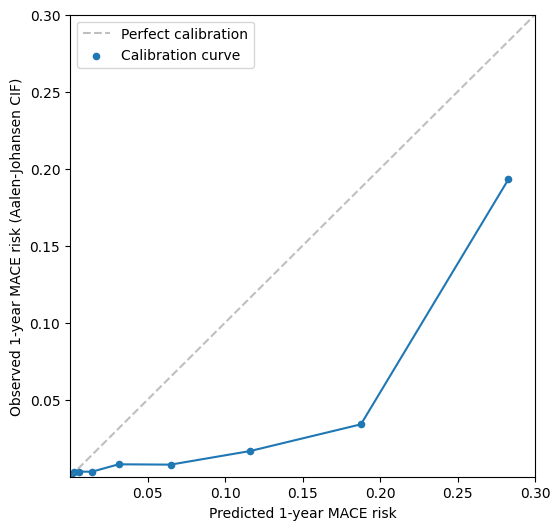

In [ ]:
# ==================================================
# DeepHit competing-risk calibration at 12 months
# ==================================================
import matplotlib.pyplot as plt
from lifelines import AalenJohansenFitter
# ==================================================
# Load data
# ==================================================
data_dir = Path(os.getenv("DATA_DIR"))
path = data_dir / "Region_sthlm_Gotland_model_data_binary.csv"

x_dim, (data, time, label), (mask1, mask2), feature_names = impt.import_dataset(path,time_scale=1.2)

# Normalize age and log-transform certain features
data[:, 0] = (data[:, 0] - data[:, 0].mean()) / data[:, 0].std()

for j in range(data.shape[1] - 3, data.shape[1]): 
    data[:, j] = np.log1p(data[:, j])
    data[:, j] = (data[:, j] - data[:, j].mean()) / data[:, j].std()

# --------------------------------------------------
# Ensure TensorFlow-compatible dtypes
# --------------------------------------------------
data   = data.astype(np.float32)
mask1  = mask1.astype(np.float32)
mask2  = mask2.astype(np.float32)
time   = time.astype(np.float32)
label  = label.astype(np.int32)   

# ==================================================
# 1. Predict from DeepHit model
# ==================================================

pred = model.call(data, training=False).numpy()

# Expected shape:
# (patients, events, time_bins)

# ==================================================
# 2. Extract predicted MACE cumulative incidence
# ==================================================

# DeepHit event index:
# 0 = MACE
# 1 = competing event

mace_index = 0

# Sum probabilities up to 12-month horizon
risk_1yr = np.sum(
    pred[:, mace_index, :eval_time[0]],
    axis=1
)

# ==================================================
# 3. Create evaluation dataframe
# ==================================================

eval_df = pd.DataFrame({

    "time": time.ravel(),

    # Keep original competing-risk labels:
    # 0 = censored
    # 1 = MACE
    # 2 = competing event
    "event": label.ravel(),

    "risk_1yr": risk_1yr

})

# ==================================================
# 4. Create predicted risk deciles
# ==================================================

eval_df["risk_decile"] = pd.qcut(
    eval_df["risk_1yr"],
    q=10,
    labels=False,
    duplicates="drop"
)

# ==================================================
# 5. Calculate observed cumulative incidence
#    using Aalen-Johansen estimator
# ==================================================

aj = AalenJohansenFitter()

calibration_results = []


for decile, group in eval_df.groupby("risk_decile"):


    # Mean predicted risk in this decile
    predicted = group["risk_1yr"].mean()


    # Fit competing-risk CIF
    aj.fit(
        durations=group["time"],
        event_observed=group["event"],
        event_of_interest=1   # observed MACE
    )

    cif = aj.cumulative_density_

    # CIF at 12 months
    available_times = cif.index[cif.index <= eval_time[0]]


    if len(available_times) > 0:

        observed = cif.loc[
            available_times[-1]
        ].values[0]

    else:

        observed = 0



    calibration_results.append({

        "decile": int(decile)+1,

        "n": len(group),

        "predicted_risk": predicted,

        "observed_risk": observed

    })


calibration_results = pd.DataFrame(
    calibration_results
)


# ==================================================
# 6. Plot calibration curve
# ==================================================

plt.figure(figsize=(6,6))

max_value = calibration_results[
    ["predicted_risk", "observed_risk"]
].max().max()
max_value = 0.3

plt.plot(
    [0, max_value],
    [0, max_value],
    "--",
    label="Perfect calibration",
    color="gray",
    alpha=0.5
)

plt.scatter(
    calibration_results["predicted_risk"],
    calibration_results["observed_risk"],
    color="#1f77b4",
    s=20,
    label="Calibration curve"
)

plt.plot(
    calibration_results["predicted_risk"],
    calibration_results["observed_risk"],
    "-",
    color="#1f77b4"
)

plt.xlabel(
    "Predicted 1-year MACE risk"
)

plt.ylabel(
    "Observed 1-year MACE risk (Aalen-Johansen CIF)"
)


plt.xlim(2e-6, max_value)
plt.ylim(2e-6, max_value)
#plt.xscale("log")
#plt.yscale("log")

plt.legend()
plt.grid(False)

plt.show()

In [ ]:
# ==================================================
# Calibration slope and intercept
# ==================================================

import statsmodels.api as sm


# Avoid log(0) and log(1)
eps = 1e-16


# Convert predicted probability to log-odds
eval_df["logit_predicted_risk"] = np.log(
    (eval_df["risk_1yr"] + eps) /
    (1 - eval_df["risk_1yr"] + eps)
)


# Define observed 1-year MACE outcome
# MACE happened AND occurred before/equal to 12 months
eval_df["MACE_1yr"] = (
    (eval_df["event"] == 1) &
    (eval_df["time"] <= eval_time[0])
).astype(int)



# Logistic calibration model
# logit(observed MACE) = intercept + slope*logit(predicted risk)

X = sm.add_constant(
    eval_df["logit_predicted_risk"]
)

y = eval_df["MACE_1yr"]


calibration_model = sm.Logit(
    y,
    X
).fit()



# Extract values

calibration_intercept = (
    calibration_model.params["const"]
)

calibration_slope = (
    calibration_model.params["logit_predicted_risk"]
)


print("--------------------------------")
print("Calibration intercept:",
      calibration_intercept)

print("Calibration slope:",
      calibration_slope)

print("--------------------------------")

Optimization terminated successfully.
         Current function value: 0.089532
         Iterations 11
--------------------------------
Calibration intercept: -0.4246454567620672
Calibration slope: 1.4932878871948556
--------------------------------


--------------------------------
Brier score at 12 months: [0.02731366]
Integrated Brier Score: 0.03779171976567957
--------------------------------


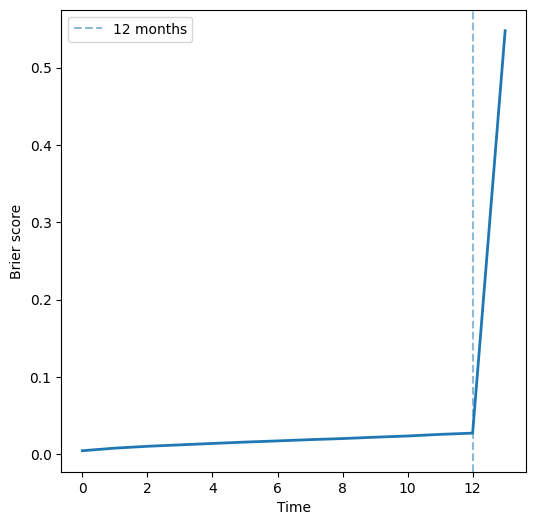

In [12]:
# ==================================================
# 1. Predictions from DeepHit
# ==================================================

pred = model.call(data, training=False).numpy()

# pred shape:
# (N patients, K events, T time bins)

mace_index = 0


# ==================================================
# 2. Convert DeepHit PMF to cumulative incidence
# ==================================================

# CIF(t) = cumulative sum of event probability over time

mace_cif = np.cumsum(
    pred[:, mace_index, :],
    axis=1
)


# ==================================================
# 3. Define time grid
# ==================================================

# DeepHit time bins
time_grid = np.arange(
    mace_cif.shape[1]
)


# ==================================================
# 4. Brier score calculation
# ==================================================

brier_scores = []


for t in time_grid:

    # predicted probability of MACE by time t
    pred_risk = mace_cif[:, t]


    # Observed outcome at time t
    # MACE occurred before/equal t
    observed = (
        (label.ravel() == 1) &
        (time.ravel() <= t)
    ).astype(int)


    # Ignore competing events for simple Brier estimate
    bs = np.mean(
        (pred_risk - observed) ** 2
    )


    brier_scores.append(bs)



brier_scores = np.array(
    brier_scores
)


# ==================================================
# 5. Brier score at 12 months
# ==================================================

brier_12 = brier_scores[eval_time]


print("--------------------------------")
print("Brier score at 12 months:",
      brier_12)


# ==================================================
# 6. Integrated Brier Score (IBS)
# ==================================================

ibs = np.trapezoid(
    brier_scores,
    time_grid
) / (
    time_grid[-1] - time_grid[0]
)


print("Integrated Brier Score:",
      ibs)

print("--------------------------------")



# ==================================================
# 7. Plot Brier score over time
# ==================================================

plt.figure(figsize=(6,6))

plt.plot(
    time_grid,
    brier_scores,
    linewidth=2
)

plt.axvline(
    eval_time,
    linestyle="--",
    alpha=0.5,
    label="12 months"
)


plt.xlabel("Time")
plt.ylabel("Brier score")


plt.legend()

plt.show()

   threshold  Predictive_model  Treat_all  Treat_none
0      0.000          0.025924   0.025924         0.0
1      0.005          0.022274   0.021029         0.0
2      0.010          0.019491   0.016085         0.0
3      0.030          0.011262  -0.004202         0.0
4      0.050          0.005151  -0.025343         0.0
5      0.075         -0.001038  -0.053055         0.0
6      0.100         -0.005133  -0.082306         0.0


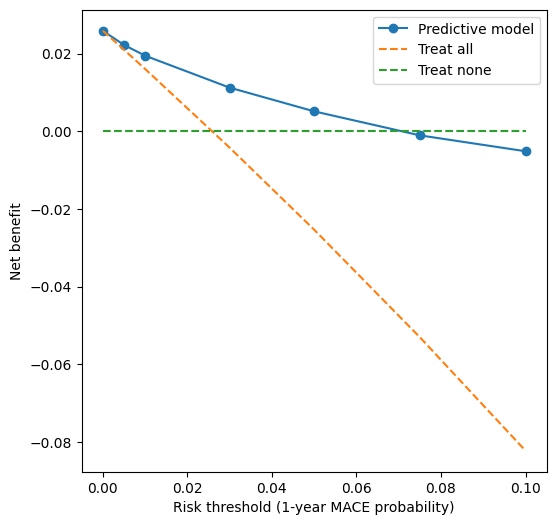

In [ ]:
# ==================================================
# 1. Define observed 1-year MACE outcome
# ==================================================

eval_df["MACE_1yr"] = (
    (eval_df["event"] == 1) &
    (eval_df["time"] <= eval_time[0])
).astype(int)



# ==================================================
# 2. Net benefit function
# ==================================================

def calculate_net_benefit(
    y_true,
    predicted_risk,
    threshold
):

    # classify patients as high risk
    predicted_positive = (
        predicted_risk >= threshold
    )


    TP = np.sum(
        predicted_positive & (y_true == 1)
    )

    FP = np.sum(
        predicted_positive & (y_true == 0)
    )


    N = len(y_true)


    net_benefit = (
        TP / N
        -
        (FP / N) *
        (threshold / (1 - threshold))
    )


    return net_benefit



# ==================================================
# 3. Thresholds
# ==================================================

thresholds = np.array([
    0,
    0.005,
    0.01,
    0.03,
    0.05,
    0.075,
    0.10
])


y_true = eval_df["MACE_1yr"].values

predicted_risk = eval_df["risk_1yr"].values



# ==================================================
# 4. Model net benefit
# ==================================================

model_nb = []


for t in thresholds:

    nb = calculate_net_benefit(
        y_true,
        predicted_risk,
        t
    )

    model_nb.append(nb)



# ==================================================
# 5. Reference strategies
# ==================================================

N = len(y_true)

prevalence = np.mean(y_true)


# Treat everyone

all_nb = (
    prevalence
    -
    (1 - prevalence)
    *
    (thresholds / (1-thresholds))
)


# Treat nobody

none_nb = np.zeros(
    len(thresholds)
)



# ==================================================
# 6. Results table
# ==================================================

dca_results = pd.DataFrame({

    "threshold": thresholds,

    "Predictive_model": model_nb,

    "Treat_all": all_nb,

    "Treat_none": none_nb

})


print(dca_results)



# ==================================================
# 7. Plot DCA curve
# ==================================================

plt.figure(figsize=(6,6))


plt.plot(
    thresholds,
    model_nb,
    marker="o",
    label="Predictive model"
)


plt.plot(
    thresholds,
    all_nb,
    linestyle="--",
    label="Treat all"
)


plt.plot(
    thresholds,
    none_nb,
    linestyle="--",
    label="Treat none"
)

plt.xlabel(
    "Risk threshold (1-year MACE probability)"
)

plt.ylabel(
    "Net benefit"
)

plt.legend()

plt.grid(False)

plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


E0000 00:00:1787036930.897696 5098259 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


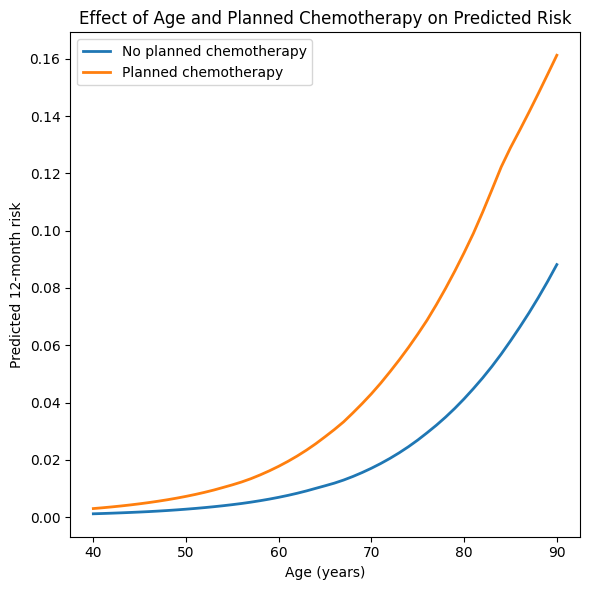

In [ ]:
# ==========================================================
# Create patients with varying age
# ==========================================================

ages = np.arange(40, 91)


patients = pd.DataFrame(
    np.repeat(reference_patient.values[None, :], len(ages), axis=0),
    columns=reference_patient.index,
)

patients["Age"] = (ages - age_mean) / age_std
# ==========================================================
# Create two scenarios:
#   1. No previous CVD
#   2. Previous CVD
# ==========================================================

patients_no_cvd = patients.copy()
patients_no_cvd["chemo"] = 0

patients_with_cvd = patients.copy()
patients_with_cvd["chemo"] = 1

# ==========================================================
# Predict cumulative incidence
# ==========================================================

pred_no_cvd = model.predict(patients_no_cvd)
pred_with_cvd = model.predict(patients_with_cvd)

# Predicted 12-month cumulative incidence
# Sum monthly probabilities over the first 12 months
risk_no_cvd = pred_no_cvd[:, :, :12].sum(axis=2)
risk_with_cvd = pred_with_cvd[:, :, :12].sum(axis=2)

# Select the event of interest (e.g. event 0 = MACE)
event_index = 0

risk_no_cvd = risk_no_cvd[:, event_index]
risk_with_cvd = risk_with_cvd[:, event_index]

# ==========================================================
# Plot age-risk curves
# ==========================================================

plt.figure(figsize=(6, 6))

plt.plot(
    ages,
    risk_no_cvd,
    linewidth=2,
    label="No planned chemotherapy",
)

plt.plot(
    ages,
    risk_with_cvd,
    linewidth=2,
    label="Planned chemotherapy",
)

plt.xlabel("Age (years)")
plt.ylabel("Predicted 12-month risk")
plt.title("Effect of Age and Planned Chemotherapy on Predicted Risk")
plt.legend()
plt.tight_layout()
plt.show()

Complete dataset shape: (15931, 88)
Cumulative-incidence output shape: (2, 13)
Background data shape: (50, 88)
Explained data shape: (15931, 88)
Calculating SHAP values for all patients...


PermutationExplainer explainer: 15932it [09:22, 28.00it/s]                           


Time-dependent SHAP shape: (15931, 88, 13)
Mean reconstruction error: 9.799045246548974e-11
Maximum reconstruction error: 7.978329941149553e-10

Global time-dependent SHAP importance:
   Feature_index     Feature  Mean_integrated_absolute_SHAP
0              0   Feature_1                       0.269534
1             87  Feature_88                       0.099501
2              7   Feature_8                       0.095585
3              9  Feature_10                       0.076572
4             32  Feature_33                       0.069728
5             86  Feature_87                       0.067734
6             28  Feature_29                       0.067400
7             85  Feature_86                       0.055457
8             34  Feature_35                       0.042857
9             26  Feature_27                       0.038415


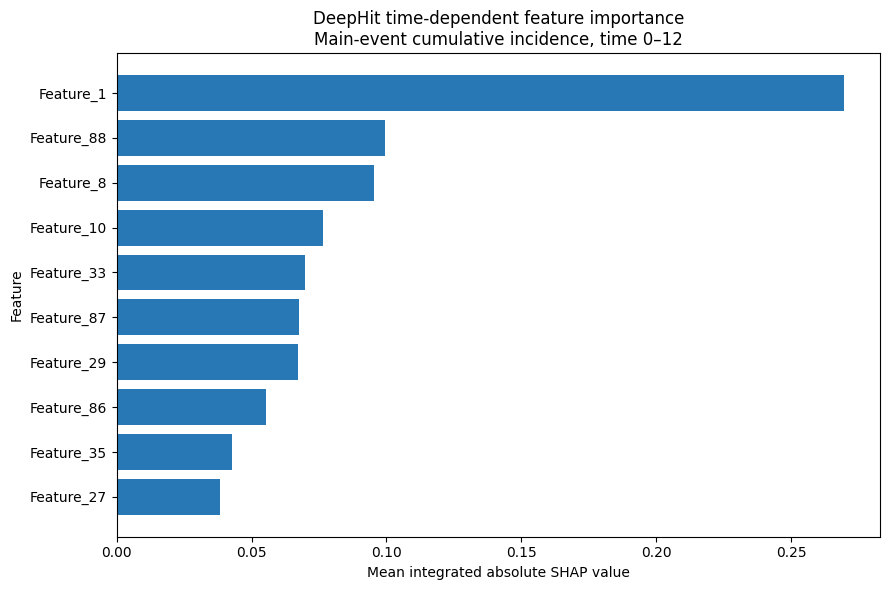

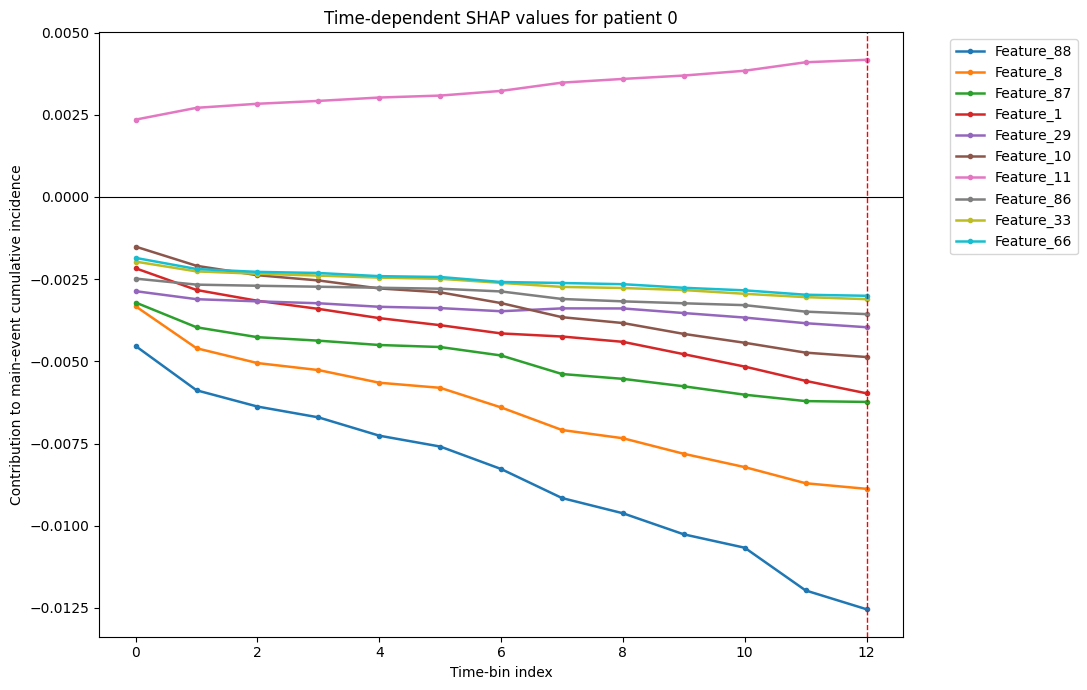

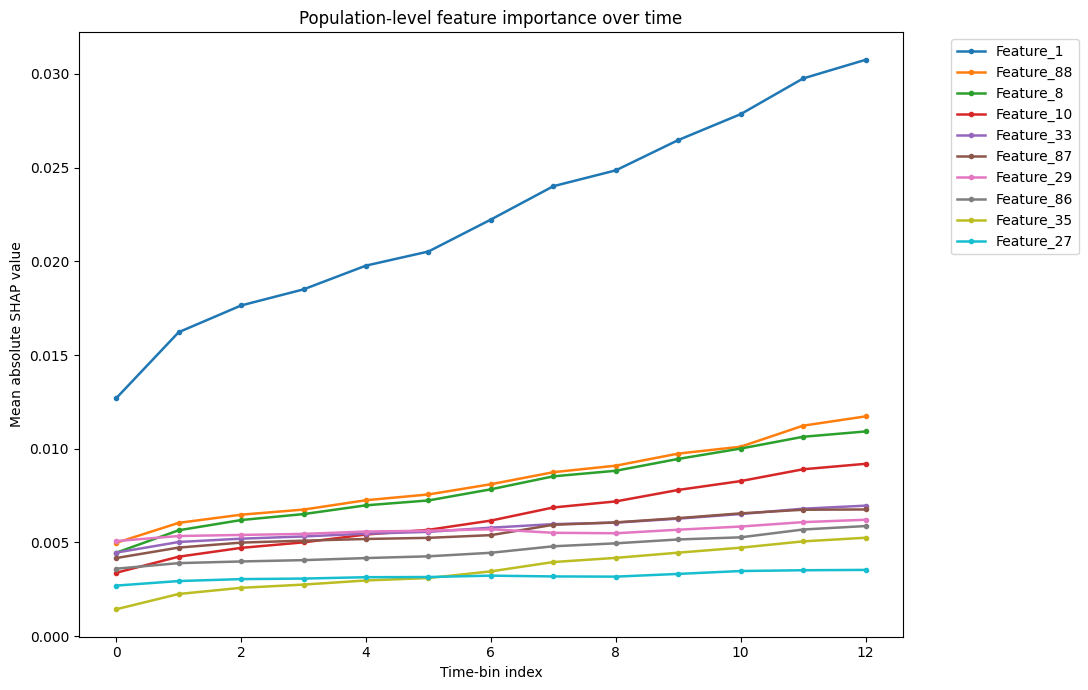

/var/folders/vj/tlj0y71x381bb5cfc_8ylv2nf7_f43/T/ipykernel_28904/1501395165.py:465: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


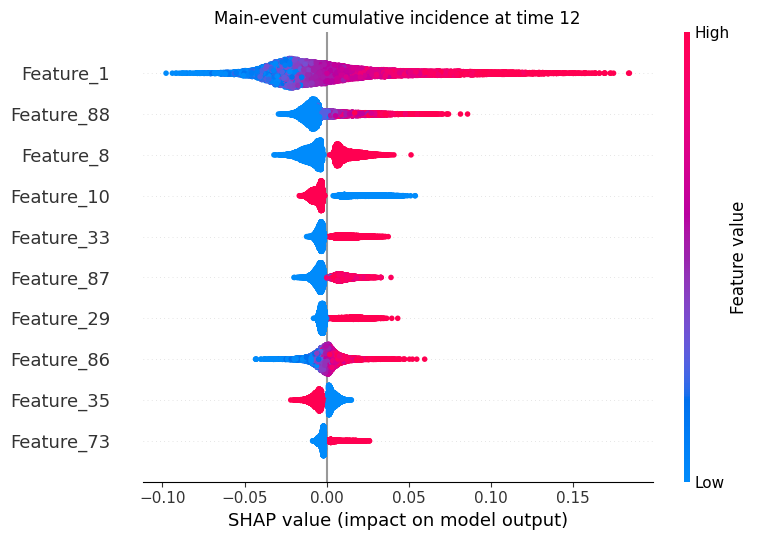

In [6]:
# ============================================================
# TIME-DEPENDENT SHAP FOR A TRAINED DEEPHIT MODEL
#
# Required existing objects:
#   model = trained DeepHitPlus model
#   data  = complete input dataset used for training
#
# Expected model output:
#   patients × events × time_bins
# ============================================================

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt


# ============================================================
# 1. Settings
# ============================================================

SEED = 321

# 0 = main event
# 1 = competing event
EVENT_INDEX = 0

# Calculate cumulative incidence through time bin 12
HORIZON = 12

# Number of background patients used by SHAP
# This is only a reference sample—not a train/test split
N_BACKGROUND = 50

TOP_FEATURES = 10


# ============================================================
# 2. Prepare the complete dataset
# ============================================================

# If data is a DataFrame, use its column names
if isinstance(data, pd.DataFrame):
    feature_names = data.columns.tolist()
    data_array = data.to_numpy(dtype=np.float32)
else:
    data_array = np.asarray(data, dtype=np.float32)
    feature_names = [
        f"Feature_{i + 1}"
        for i in range(data_array.shape[1])
    ]

if data_array.ndim != 2:
    raise ValueError(
        "data must have shape: patients × features."
    )

print("Complete dataset shape:", data_array.shape)


# ============================================================
# 3. DeepHit cumulative-incidence prediction
# ============================================================

def predict_main_event_cif(x):
    """
    Return the cumulative incidence of the main event
    from time bin 0 through HORIZON.
    """

    x = np.asarray(x, dtype=np.float32)

    # DeepHit probability mass function:
    # patients × events × time_bins
    pred = model(x, training=False).numpy()

    if pred.ndim != 3:
        raise ValueError(
            "Expected model output with shape "
            "(patients, events, time_bins), "
            f"but received {pred.shape}."
        )

    if EVENT_INDEX >= pred.shape[1]:
        raise ValueError(
            f"EVENT_INDEX={EVENT_INDEX} is outside the "
            f"{pred.shape[1]} model events."
        )

    if HORIZON >= pred.shape[2]:
        raise ValueError(
            f"HORIZON={HORIZON} is outside the "
            f"{pred.shape[2]} model time bins."
        )

    event_pmf = pred[
        :,
        EVENT_INDEX,
        :(HORIZON + 1)
    ]

    return np.cumsum(event_pmf, axis=1)


# Check model output
test_prediction = predict_main_event_cif(
    data_array[:2]
)

print(
    "Cumulative-incidence output shape:",
    test_prediction.shape
)


# ============================================================
# 4. Prepare SHAP data
# ============================================================

# Explain every patient in the complete dataset
explain_data = data_array

# Select a reference sample from the same complete dataset.
# This does not split the data and does not retrain the model.
rng = np.random.default_rng(SEED)

n_background = min(
    N_BACKGROUND,
    data_array.shape[0]
)

background_indices = rng.choice(
    data_array.shape[0],
    size=n_background,
    replace=False
)

background_data = data_array[
    background_indices
]

print("Background data shape:", background_data.shape)
print("Explained data shape:", explain_data.shape)


# ============================================================
# 5. Create permutation SHAP explainer
# ============================================================

masker = shap.maskers.Independent(
    background_data,
    max_samples=n_background
)

time_labels = [
    f"Time_{time_index}"
    for time_index in range(HORIZON + 1)
]

explainer = shap.Explainer(
    predict_main_event_cif,
    masker=masker,
    algorithm="permutation",
    feature_names=feature_names,
    output_names=time_labels,
    seed=SEED
)

minimum_evaluations = (
    2 * data_array.shape[1] + 1
)

max_evaluations = max(
    500,
    minimum_evaluations
)

print("Calculating SHAP values for all patients...")

explanation = explainer(
    explain_data,
    max_evals=max_evaluations,
    batch_size=128
)


# ============================================================
# 6. Extract and verify SHAP values
# ============================================================

time_shap = np.asarray(
    explanation.values
)

expected_shape = (
    data_array.shape[0],
    data_array.shape[1],
    HORIZON + 1
)

print("Time-dependent SHAP shape:", time_shap.shape)

if time_shap.shape != expected_shape:
    raise ValueError(
        f"Expected SHAP shape {expected_shape}, "
        f"but received {time_shap.shape}."
    )

predicted_cif = predict_main_event_cif(
    explain_data
)

base_values = np.asarray(
    explanation.base_values
)

if base_values.ndim == 1:
    base_values = np.broadcast_to(
        base_values,
        predicted_cif.shape
    )

reconstructed_cif = (
    base_values
    + np.sum(time_shap, axis=1)
)

reconstruction_error = np.abs(
    predicted_cif - reconstructed_cif
)

print(
    "Mean reconstruction error:",
    reconstruction_error.mean()
)

print(
    "Maximum reconstruction error:",
    reconstruction_error.max()
)


# ============================================================
# 7. Calculate integrated time-dependent importance
# ============================================================

time_points = np.arange(
    HORIZON + 1,
    dtype=float
)

if hasattr(np, "trapezoid"):
    integrated_shap = np.trapezoid(
        np.abs(time_shap),
        x=time_points,
        axis=2
    )
else:
    integrated_shap = np.trapz(
        np.abs(time_shap),
        x=time_points,
        axis=2
    )

# Mean integrated absolute SHAP across all patients
global_importance = np.mean(
    integrated_shap,
    axis=0
)

importance_table = pd.DataFrame({
    "Feature_index": np.arange(len(feature_names)),
    "Feature": feature_names,
    "Mean_integrated_absolute_SHAP":
        global_importance
})

importance_table = importance_table.sort_values(
    "Mean_integrated_absolute_SHAP",
    ascending=False
).reset_index(drop=True)

print("\nGlobal time-dependent SHAP importance:")
print(importance_table.head(TOP_FEATURES))

importance_table.to_csv(
    "DeepHit_time_dependent_SHAP_importance.csv",
    index=False
)


# ============================================================
# 8. Global integrated-importance plot
# ============================================================

global_plot_data = (
    importance_table
    .head(TOP_FEATURES)
    .sort_values(
        "Mean_integrated_absolute_SHAP",
        ascending=True
    )
)

plt.figure(figsize=(9, 6))

plt.barh(
    global_plot_data["Feature"],
    global_plot_data[
        "Mean_integrated_absolute_SHAP"
    ],
    color="#2878B5"
)

plt.xlabel("Mean integrated absolute SHAP value")
plt.ylabel("Feature")

plt.title(
    "DeepHit time-dependent feature importance\n"
    f"Main-event cumulative incidence, time 0–{HORIZON}"
)

plt.tight_layout()

plt.savefig(
    "DeepHit_global_time_dependent_SHAP.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 9. Plot time-dependent SHAP for one patient
# ============================================================

patient_position = 0

patient_importance = integrated_shap[
    patient_position
]

patient_top_indices = np.argsort(
    -patient_importance
)[:TOP_FEATURES]

plt.figure(figsize=(11, 7))

for feature_index in patient_top_indices:
    plt.plot(
        time_points,
        time_shap[
            patient_position,
            feature_index,
            :
        ],
        marker="o",
        markersize=3,
        linewidth=1.8,
        label=feature_names[feature_index]
    )

plt.axhline(
    0,
    color="black",
    linewidth=0.8
)

plt.axvline(
    HORIZON,
    color="red",
    linestyle="--",
    linewidth=1
)

plt.xlabel("Time-bin index")

plt.ylabel(
    "Contribution to main-event cumulative incidence"
)

plt.title(
    f"Time-dependent SHAP values for patient "
    f"{patient_position}"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "DeepHit_patient_time_dependent_SHAP.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 10. Population-level importance over time
# ============================================================

mean_absolute_shap_by_time = np.mean(
    np.abs(time_shap),
    axis=0
)

global_top_indices = np.argsort(
    -global_importance
)[:TOP_FEATURES]

plt.figure(figsize=(11, 7))

for feature_index in global_top_indices:
    plt.plot(
        time_points,
        mean_absolute_shap_by_time[
            feature_index,
            :
        ],
        marker="o",
        markersize=3,
        linewidth=1.8,
        label=feature_names[feature_index]
    )

plt.xlabel("Time-bin index")
plt.ylabel("Mean absolute SHAP value")

plt.title(
    "Population-level feature importance over time"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "DeepHit_population_time_dependent_SHAP.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 11. Standard SHAP summary at the selected horizon
# ============================================================

shap_at_horizon = time_shap[
    :,
    :,
    HORIZON
]

shap.summary_plot(
    shap_at_horizon,
    explain_data,
    feature_names=feature_names,
    max_display=TOP_FEATURES,
    show=False
)

plt.title(
    f"Main-event cumulative incidence at time {HORIZON}"
)

plt.tight_layout()

plt.savefig(
    f"DeepHit_SHAP_summary_at_horizon_{HORIZON}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
feature_names[85
              ]

'VisitCount'